dt = 0.100 ms
alpha = 0.048771
-3 dB cutoff frequency = 79.48 Hz


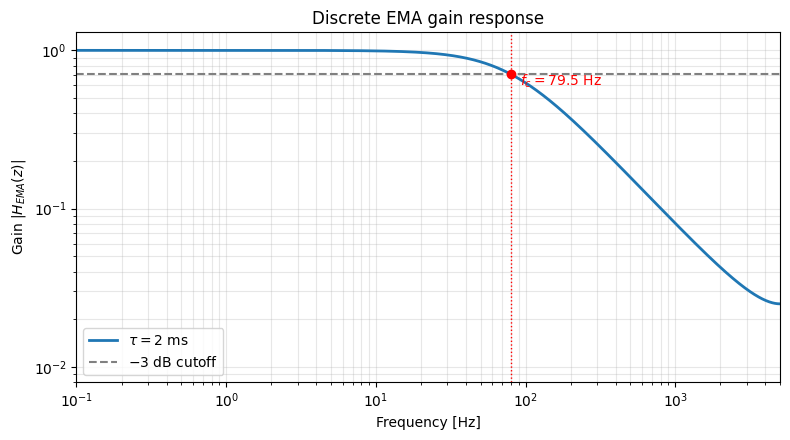

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ========================================
# 設定
# ========================================

FS_HZ = 10000.0
TAU_MS = 2.0

# サンプリング間隔
dt = 1.0 / FS_HZ
dt_ms = dt * 1000.0

# 時定数
tau = TAU_MS * 1e-3

# ナイキスト周波数
f_nyquist = FS_HZ / 2.0

# ========================================
# EMAの伝達関数
# ========================================

# y[n] = alpha*x[n] + (1-alpha)*y[n-1]
alpha = 1.0 - np.exp(-dt / tau)

# 0.1 Hz～ナイキスト周波数
frequency = np.logspace(np.log10(0.1),np.log10(f_nyquist),3000)

# デジタル角周波数
omega = 2.0 * np.pi * frequency * dt

# H(z) = alpha / {1 - (1-alpha)z^(-1)}
H_EMA = alpha / (1.0- (1.0 - alpha) * np.exp(-1j * omega))

gain = np.abs(H_EMA)

# ========================================
# -3 dB遮断周波数
# ========================================
cutoff_gain = 10.0 ** (-3.0 / 20.0)

# -3 dBに最も近い周波数
cutoff_index = np.argmin(np.abs(gain - cutoff_gain))
cutoff_frequency = frequency[cutoff_index]

print(f"dt = {dt_ms:.3f} ms")
print(f"alpha = {alpha:.6f}")
print(f"-3 dB cutoff frequency = {cutoff_frequency:.2f} Hz")

# ========================================
# グラフ
# ========================================

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.loglog(
    frequency,
    gain,
    linewidth=2,
    label=rf"$\tau={TAU_MS:g}$ ms"
)

# -3 dBの水平線
ax.axhline(
    cutoff_gain,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=r"$-3$ dB cutoff"
)

# 遮断周波数の位置
ax.plot(
    cutoff_frequency,
    cutoff_gain,
    marker="o",
    color="red",
    markersize=6
)

ax.axvline(
    cutoff_frequency,
    color="red",
    linestyle=":",
    linewidth=1
)

ax.text(
    cutoff_frequency * 1.15,
    cutoff_gain * 0.85,
    rf"$f_c={cutoff_frequency:.1f}$ Hz",
    color="red"
)

ax.set_title("Discrete EMA gain response")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Gain $|H_{EMA}(z)|$")

ax.set_xlim(0.1, f_nyquist)
ax.set_ylim(8e-3, 1.3)

ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

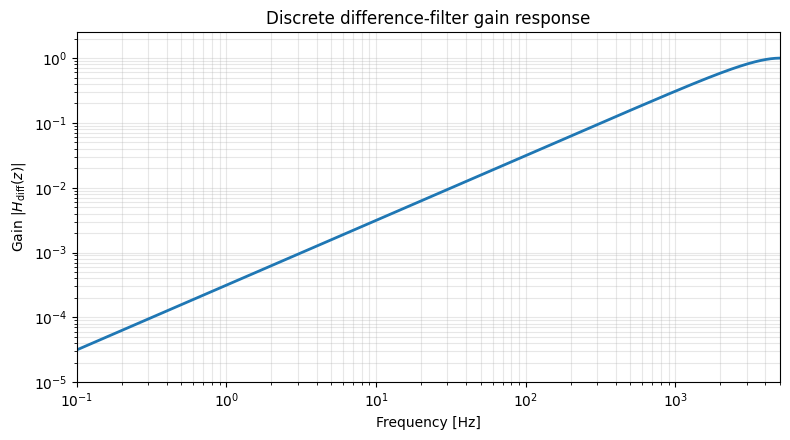

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ========================================
# 設定
# ========================================

FS_HZ = 10000.0
DIFF_WIDTH = 1

# サンプリング間隔
dt = 1.0 / FS_HZ
dt_ms = dt * 1000.0

# ナイキスト周波数
f_nyquist = FS_HZ / 2.0

# ========================================
# 差分フィルタの伝達関数
# ========================================

# 0.1 Hz～ナイキスト周波数
frequency = np.logspace(
    np.log10(0.1),
    np.log10(f_nyquist),
    3000
)

# デジタル角周波数
omega = 2.0 * np.pi * frequency / FS_HZ

# y[n] = x[n] - x[n-D]
# H_diff(z) = 1 - z^(-D)
H_diff = (
    1.0
    - np.exp(-1j * omega * DIFF_WIDTH)
)

# 最大ゲインが1になるように正規化
gain = np.abs(H_diff) / 2.0

# ========================================
# グラフ
# ========================================
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.loglog(
    frequency,
    gain,
    linewidth=2,
)

ax.set_title("Discrete difference-filter gain response")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Gain $|H_{\mathrm{diff}}(z)|$")

ax.set_xlim(0.1, f_nyquist)
ax.set_ylim(1e-5, 2.5)

ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

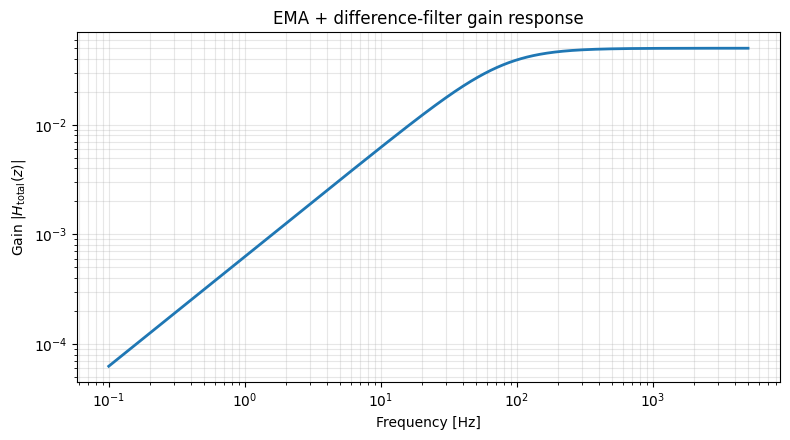

In [6]:
H_total = H_EMA * H_diff

plt.figure(figsize=(8, 4.5))
plt.loglog(frequency, np.abs(H_total), linewidth=2)

plt.title("EMA + difference-filter gain response")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Gain $|H_{\mathrm{total}}(z)|$")
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()